# 10. Options income strategies backtesting

Post-assignment policy comparison across 5 CSP yield targets.

**Dimensions:**

- **Axis 1 - Base policy** (how to handle assigned shares):
  1. `liquidate` - sell at next Monday close
  2. `hold_idle_*` - wait for `close >= assigned_strike`, no CC
  3. `strict_wheel_*` - CC only at `strike >= assigned_strike`
  4. `safe_wheel_*` - strict first, else furthest-OTM CC
  5. `aggressive_wheel_*` - always sell CC at target yield

- **Axis 2 - Stops** (forced resolution):
  - `_no_stops` - let the base policy run indefinitely
  - `_stops` - time stop after 8 weeks OR drawdown stop at -20% (daily scan)

- **Axis 3 - CSP entry yield target**: ['1%', '2%', '3%', '4%', '5%']

**Total runs:** 9 policies x 5 yields = 45 series.

**Output artifact:** `data/backtest_results.parquet` - one row per (policy, yield_target, ticker, monday_date) with the weekly PnL / capital contribution. Portfolio-level returns are computed from this by equal-weighting across HQ tickers (all 35).

**Framework:**

- Fixed per-ticker notional (equal weight, no rebalance); capital sized to the first CSP's collateral per ticker.
- Weekly portfolio return = mean of per-ticker PnL-% across 35 tickers. Idle weeks contribute 0.
- Compounded geometrically for the equity curve.
- Fees: Webull Thailand post-promo ($0.55 commission × 1.07 VAT + regulatory fees on option sell; stock commission on unwind).
- No borrow fees, no dividend handling, no tax drag.


In [1]:
import math
import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import HIGH_QUALITY_TICKERS


LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
RESULTS_PATH = Path("output/06_options_income_strategies_backtesting/backtest_results.parquet")
RESULTS_CSV = Path("output/06_options_income_strategies_backtesting/backtest_results.csv")

YIELD_TARGETS = [0.01, 0.02, 0.03, 0.04, 0.05]
BNH_NOTIONAL = 10_000.0
BNH_MIN_FIRST_CLOSE = 1.0
POLICIES = [
    "buy_and_hold_spy",
    "liquidate",
    "hold_idle_no_stops",
    "hold_idle_stops",
    "strict_wheel_no_stops",
    "strict_wheel_stops",
    "safe_wheel_no_stops",
    "safe_wheel_stops",
    "aggressive_wheel_no_stops",
    "aggressive_wheel_stops",
]

TIME_STOP_WEEKS = 8
DRAWDOWN_STOP = 0.20
MIN_BID = 0.05
EXPECTED_DTE = 4

WINDOW_START = pd.Timestamp("2020-01-01")
WINDOW_END = pd.Timestamp("2026-04-02")
BNH_NOTIONAL = 10_000.0

VAT = 1.07
CC_OPTIONS_COLS = [
    "contractID",
    "expiration",
    "strike",
    "type",
    "bid",
    "ask",
    "mark",
    "open_interest",
    "delta",
]
DATE_RE = re.compile(r"_(\d{4}-\d{2}-\d{2})\.csv$")

## Fee model (Webull Thailand, post-promo)

Option sell-to-open: $0.55 commission × 1.07 VAT + SEC/FINRA/ORF/Clearing fees. Assignment/exercise: $0. Stock unwind (liquidate, stop-out, policy-2 breakeven exit): 0.107% commission × 1.07 VAT + SEC/FINRA sell fees.


In [2]:
def option_entry_fee(premium_per_share):
    commission = 0.55 * VAT
    sec = max(0.01, 0.0000206 * premium_per_share * 100)
    taf = max(0.01, 0.00329)
    orf = 0.02295
    clear = max(0.02, 0.025)
    return commission + sec + taf + orf + clear


def stock_unwind_fee(price):
    notional = price * 100
    commission = 0.001 * notional * VAT
    sec = max(0.01, 0.0000206 * notional)
    taf = min(9.79, max(0.01, 0.000195 * 100))
    cat = max(0.01, 0.000024 * 100)
    return commission + sec + taf + cat

## Load + preload caches

- Labels base table -> CSP entry lookups indexed by `(ticker, monday, yield_target)`
- Daily OHLC per HQ ticker -> for MTM, monday close, daily drawdown check
- CC chain snippets per `(ticker, monday)` -> only same-week-Friday calls with `bid >= MIN_BID`, keeps memory small


In [3]:
labels = pd.read_parquet(LABELS_PATH)
csp_rows = labels[labels["type"] == "CSP"].copy()
csp_rows["monday_date"] = pd.to_datetime(csp_rows["monday_date"]).dt.date
csp_index = {}
for row in csp_rows.itertuples():
    key = (row.ticker, row.monday_date, round(row.yield_target, 4))
    csp_index[key] = row

daily_cache = {}
split_events = {}
for t in HIGH_QUALITY_TICKERS:
    p = Path("data/daily_alpha") / f"{t}.csv"
    if not p.exists():
        daily_cache[t] = {}
        split_events[t] = {}
        continue
    df = pd.read_csv(
        p, usecols=["date", "open", "high", "low", "close", "split_coefficient"]
    )
    df["date"] = pd.to_datetime(df["date"]).dt.date
    daily_cache[t] = {
        row.date: (float(row.open), float(row.high), float(row.low), float(row.close))
        for row in df.itertuples()
    }
    split_events[t] = {
        row.date: float(row.split_coefficient)
        for row in df.itertuples()
        if float(row.split_coefficient) != 1.0
    }

monday_list = {
    t: sorted(d for d in daily_cache[t] if d.weekday() == 0)
    for t in HIGH_QUALITY_TICKERS
}

chain_cache = {t: {} for t in HIGH_QUALITY_TICKERS}
for t in HIGH_QUALITY_TICKERS:
    tdir = Path("data/options_alpha") / t
    if not tdir.is_dir():
        continue
    for f in tdir.iterdir():
        m = DATE_RE.search(f.name)
        if not m:
            continue
        snap = pd.Timestamp(m.group(1))
        if snap.weekday() != 0:
            continue
        try:
            df = pd.read_csv(f, usecols=CC_OPTIONS_COLS)
        except Exception:
            continue
        for col in ("bid", "ask", "mark", "delta", "open_interest", "strike"):
            df[col] = pd.to_numeric(df[col], errors="coerce")
        df = df.dropna(subset=["delta", "mark", "bid", "ask", "strike"])
        df["expiration"] = pd.to_datetime(df["expiration"])
        friday = snap + pd.Timedelta(days=EXPECTED_DTE)
        df = df[
            (df["expiration"].dt.date == friday.date())
            & (df["type"] == "call")
            & (df["bid"] >= MIN_BID)
        ]
        if df.empty:
            continue
        chain_cache[t][snap.date()] = df[
            ["strike", "bid", "ask", "mark", "delta", "open_interest", "contractID"]
        ].reset_index(drop=True)

print(f"loaded {len(labels):,} labels")
print(f"csp_index: {len(csp_index):,} entries")
print(f"daily_cache: {sum(len(v) for v in daily_cache.values()):,} total daily rows")
print(
    f"chain_cache: {sum(len(v) for v in chain_cache.values()):,} (ticker, monday) CC slices"
)

loaded 64,339 labels
csp_index: 31,398 entries
daily_cache: 129,578 total daily rows
chain_cache: 7,187 (ticker, monday) CC slices
split_events: 39 splits detected across universe


## State machine and backtest runner

Per-ticker state has `mode in {"idle", "holding"}`, `assigned_strike`, `ref_price` (last MTM reference), `weeks_held`. The `run_backtest(policy, yield_target)` iterates every Monday for every ticker, producing a `(ticker, monday) -> weekly_pnl_pct` map.

Weekly PnL uses bid-fill on options (conservative), mark-to-market on held shares between Mondays, Friday-close outcome for CC assignment, and daily-low scan for drawdown stop detection.


In [4]:
@dataclass
class TickerState:
    mode: str = "idle"
    shares: int = 0
    assigned_strike: float = 0.0
    ref_price: float = 0.0
    weeks_held: int = 0


def apply_splits_in_range(ticker, start_date, end_date, state):
    """Apply any split events in (start_date, end_date] to the holding state."""
    for d, coef in split_events.get(ticker, {}).items():
        if start_date < d <= end_date and state.mode == "holding":
            state.shares = int(round(state.shares * coef))
            state.assigned_strike /= coef
            state.ref_price /= coef


def pick_cc_strict(chain, assigned_strike, yield_target, spot):
    cands = chain[chain["strike"] >= assigned_strike]
    if cands.empty:
        return None
    yields = cands["mark"] / spot
    idx = (yields - yield_target).abs().idxmin()
    return cands.loc[idx]


def pick_cc_safe(chain, assigned_strike, yield_target, spot):
    s = pick_cc_strict(chain, assigned_strike, yield_target, spot)
    if s is not None:
        return s
    idx = chain["delta"].abs().idxmin()
    return chain.loc[idx]


def pick_cc_aggressive(chain, yield_target, spot):
    yields = chain["mark"] / spot
    idx = (yields - yield_target).abs().idxmin()
    return chain.loc[idx]


def check_daily_drawdown(ticker, start_date, end_date, assigned_strike, drawdown):
    daily = daily_cache[ticker]
    threshold = assigned_strike * (1 - drawdown)
    d = start_date + pd.Timedelta(days=1).to_pytimedelta()
    while d <= end_date:
        ohlc = daily.get(d)
        if ohlc is not None and ohlc[2] <= threshold:
            return d, ohlc[3]
        d += pd.Timedelta(days=1).to_pytimedelta()
    return None


def policy_flags(policy_name):
    mapping = {
        "liquidate": ("liquidate", False, False),
        "hold_idle_no_stops": ("hold_idle", False, False),
        "hold_idle_stops": ("hold_idle", True, True),
        "strict_wheel_no_stops": ("strict_wheel", False, False),
        "strict_wheel_stops": ("strict_wheel", True, True),
        "safe_wheel_no_stops": ("safe_wheel", False, False),
        "safe_wheel_stops": ("safe_wheel", True, True),
        "aggressive_wheel_no_stops": ("aggressive_wheel", False, False),
        "aggressive_wheel_stops": ("aggressive_wheel", True, True),
    }
    return mapping[policy_name]


def run_buy_and_hold_spy():
    """SPY buy-and-hold baseline with $10k notional."""
    spy = pd.read_csv("data/daily_alpha/SPY.csv", usecols=["date", "close"])
    spy["date"] = pd.to_datetime(spy["date"]).dt.date
    spy = spy[
        (spy["date"] >= WINDOW_START.date()) & (spy["date"] <= WINDOW_END.date())
    ].sort_values("date")
    spy_close = dict(zip(spy["date"], spy["close"].astype(float)))
    spy_mondays = sorted(d for d in spy_close if d.weekday() == 0)
    first_close = spy_close[spy_mondays[0]]
    shares = BNH_NOTIONAL / first_close
    ref = first_close
    weekly = {spy_mondays[0]: 0.0}
    for i in range(1, len(spy_mondays)):
        monday = spy_mondays[i]
        cur = spy_close.get(monday)
        if cur is None:
            weekly[monday] = 0.0
            continue
        pnl_dollars = shares * (cur - ref)
        ref = cur
        weekly[monday] = pnl_dollars / BNH_NOTIONAL
    return {"SPY": weekly}


def run_backtest(policy_name, yield_target):
    base, use_time, use_dd = policy_flags(policy_name)
    yt_key = round(yield_target, 4)
    per_ticker_weekly = {}
    for t in HIGH_QUALITY_TICKERS:
        state = TickerState()
        weekly = {}
        mondays = monday_list[t]
        for i, monday in enumerate(mondays):
            ohlc = daily_cache[t].get(monday)
            if ohlc is None:
                continue
            mon_close = ohlc[3]
            pnl_dollars = 0.0

            if state.mode == "idle":
                row = csp_index.get((t, monday, yt_key))
                if row is None:
                    weekly[monday] = 0.0
                    continue
                this_notional = row.capital_per_contract
                pnl_dollars += row.premium_received_bid - option_entry_fee(
                    row.premium_mark
                )
                if row.assigned:
                    pnl_dollars -= row.intrinsic_at_expiry * 100
                    state.mode = "holding"
                    state.shares = 100
                    state.assigned_strike = row.strike
                    state.ref_price = row.friday_close
                    state.weeks_held = 0
                weekly[monday] = pnl_dollars / this_notional if this_notional else 0.0
                continue

            # holding
            state.weeks_held += 1

            # Split adjustment between prev Monday and this Monday
            prev_mon = mondays[i - 1] if i > 0 else monday
            apply_splits_in_range(t, prev_mon, monday, state)

            this_notional = (
                state.assigned_strike * state.shares
                if state.shares
                else (state.assigned_strike * 100)
            )

            stopped = False
            if use_time and state.weeks_held > TIME_STOP_WEEKS:
                pnl_dollars += state.shares * (
                    mon_close - state.ref_price
                ) - stock_unwind_fee(mon_close)
                state.mode = "idle"
                state.shares = 0
                stopped = True
            if not stopped and use_dd:
                prev_fri = prev_mon + pd.Timedelta(days=EXPECTED_DTE).to_pytimedelta()
                trig = check_daily_drawdown(
                    t, prev_fri, monday, state.assigned_strike, DRAWDOWN_STOP
                )
                if trig is not None:
                    _, exit_price = trig
                    pnl_dollars += 100 * (
                        exit_price - state.ref_price
                    ) - stock_unwind_fee(exit_price)
                    state.mode = "idle"
                    state.shares = 0
                    stopped = True
            if stopped:
                weekly[monday] = pnl_dollars / this_notional
                continue

            pnl_dollars += state.shares * (mon_close - state.ref_price)
            state.ref_price = mon_close

            if base == "liquidate":
                pnl_dollars -= stock_unwind_fee(mon_close)
                state.mode = "idle"
                state.shares = 0
            elif base == "hold_idle":
                if mon_close >= state.assigned_strike:
                    pnl_dollars -= stock_unwind_fee(mon_close)
                    state.mode = "idle"
                    state.shares = 0
            elif base in ("strict_wheel", "safe_wheel", "aggressive_wheel"):
                chain = chain_cache.get(t, {}).get(monday)
                pick = None
                if chain is not None and not chain.empty:
                    if base == "strict_wheel":
                        pick = pick_cc_strict(
                            chain, state.assigned_strike, yield_target, mon_close
                        )
                    elif base == "safe_wheel":
                        pick = pick_cc_safe(
                            chain, state.assigned_strike, yield_target, mon_close
                        )
                    else:
                        pick = pick_cc_aggressive(chain, yield_target, mon_close)
                if pick is not None:
                    strike_cc = float(pick["strike"])
                    mark_cc = float(pick["mark"])
                    bid_cc = float(pick["bid"])
                    contracts = state.shares // 100
                    pnl_dollars += (
                        bid_cc * 100 * contracts - option_entry_fee(mark_cc) * contracts
                    )
                    friday = monday + pd.Timedelta(days=EXPECTED_DTE).to_pytimedelta()
                    fri = daily_cache[t].get(friday)
                    if fri is not None:
                        fri_close = fri[3]
                        if fri_close > strike_cc:
                            pnl_dollars += state.shares * (strike_cc - mon_close)
                            state.mode = "idle"
                            state.shares = 0
                        else:
                            state.ref_price = fri_close

            weekly[monday] = pnl_dollars / this_notional if this_notional > 0 else 0.0
        per_ticker_weekly[t] = weekly
    return per_ticker_weekly

## Run all 45 backtests

9 policies x 5 yield targets. Results saved to `data/backtest_results.parquet` (and a CSV peek copy).


In [5]:
import time

if RESULTS_PATH.exists():
    print(f"Loading cached results from {RESULTS_PATH}")
    results = pd.read_parquet(RESULTS_PATH)
else:
    print("Running 45 backtests (9 policies x 5 yields)...")
    t0 = time.time()
    records = []
    # buy_and_hold is yield-invariant; compute once, copy across yield targets
    bnh_weekly = run_buy_and_hold_spy()
    for policy in POLICIES:
        for yt in YIELD_TARGETS:
            if policy == "buy_and_hold_spy":
                weekly_by_ticker = bnh_weekly
            else:
                weekly_by_ticker = run_backtest(policy, yt)
            for t, weekly in weekly_by_ticker.items():
                for monday, pnl_pct in weekly.items():
                    records.append(
                        {
                            "policy": policy,
                            "yield_target": yt,
                            "ticker": t,
                            "monday_date": monday,
                            "pnl_pct": pnl_pct,
                        }
                    )
            print(f"  {policy:30s} @ {yt:.1%}: done")
    results = pd.DataFrame(records)
    results["monday_date"] = pd.to_datetime(results["monday_date"])
    print(f"\nBuilt {len(results):,} rows in {time.time() - t0:.1f}s")
    results.to_parquet(RESULTS_PATH, index=False)
    results.to_csv(RESULTS_CSV, index=False)
    print(f"Saved to {RESULTS_PATH} ({RESULTS_PATH.stat().st_size / 1024:,.1f} KB)")
    print(f"      + {RESULTS_CSV} ({RESULTS_CSV.stat().st_size / 1024:,.1f} KB)")

print(
    f"results: {len(results):,} rows, {results['policy'].nunique()} policies x {results['yield_target'].nunique()} yields"
)

Loading cached results from D:\AT82.04-Option-Screener-with-Price-Prediction\experiments\data\backtest_results.parquet
results: 1,092,690 rows, 9 policies x 5 yields


## Summary table

Portfolio metrics per (policy, yield_target). 45 rows.


In [6]:
def portfolio_series(df):
    return df.groupby("monday_date")["pnl_pct"].median().sort_index()


def metrics(weekly):
    if len(weekly) == 0:
        return dict(
            total_return=0,
            mean_weekly=0,
            std_weekly=0,
            sharpe=0,
            max_dd=0,
            calmar=0,
            n_weeks=0,
        )
    cum = weekly.cumsum()
    running_max = cum.cummax()
    dd = cum - running_max
    max_dd = float(dd.min())
    total = float(cum.iloc[-1])
    mean_w = float(weekly.mean())
    std_w = float(weekly.std())
    sharpe = mean_w / std_w * math.sqrt(52) if std_w > 0 else 0.0
    calmar = (total * 52 / len(weekly)) / abs(max_dd) if max_dd < 0 else float("nan")
    return dict(
        total_return=total,
        mean_weekly=mean_w,
        std_weekly=std_w,
        sharpe=sharpe,
        max_dd=max_dd,
        calmar=calmar,
        n_weeks=len(weekly),
    )


summary_rows = []
for policy in POLICIES:
    for yt in YIELD_TARGETS:
        sub = results[(results["policy"] == policy) & (results["yield_target"] == yt)]
        weekly = portfolio_series(sub)
        m = metrics(weekly)
        summary_rows.append({"policy": policy, "yield_target": yt, **m})
summary = pd.DataFrame(summary_rows)
summary.round(4)

,policy,yield_target,total_return,mean_weekly,std_weekly,sharpe,max_dd,calmar,n_weeks
0,buy_and_hold_spy,0.01,0.9527,0.0033,0.0354,0.6648,-0.3636,0.4665,292
1,buy_and_hold_spy,0.02,0.9527,0.0033,0.0354,0.6648,-0.3636,0.4665,292
2,buy_and_hold_spy,0.03,0.9527,0.0033,0.0354,0.6648,-0.3636,0.4665,292
3,buy_and_hold_spy,0.04,0.9527,0.0033,0.0354,0.6648,-0.3636,0.4665,292
4,buy_and_hold_spy,0.05,0.9527,0.0033,0.0354,0.6648,-0.3636,0.4665,292
5,liquidate,0.01,0.8979,0.0031,0.0044,5.0970,-0.0247,6.4835,292
6,liquidate,0.02,0.4413,0.0015,0.0051,2.1500,-0.0283,2.7719,292
7,liquidate,0.03,0.1761,0.0006,0.0035,1.2335,0.0000,NaN,292
8,liquidate,0.04,0.0642,0.0002,0.0025,0.6422,0.0000,NaN,292
9,liquidate,0.05,0.0465,0.0002,0.0022,0.5321,0.0000,NaN,292


## Heatmap: total return, Sharpe, max drawdown

Green = good, red = bad. Numbers inside each cell are the exact values; colors diverge around zero so positive/negative is obvious at a glance.


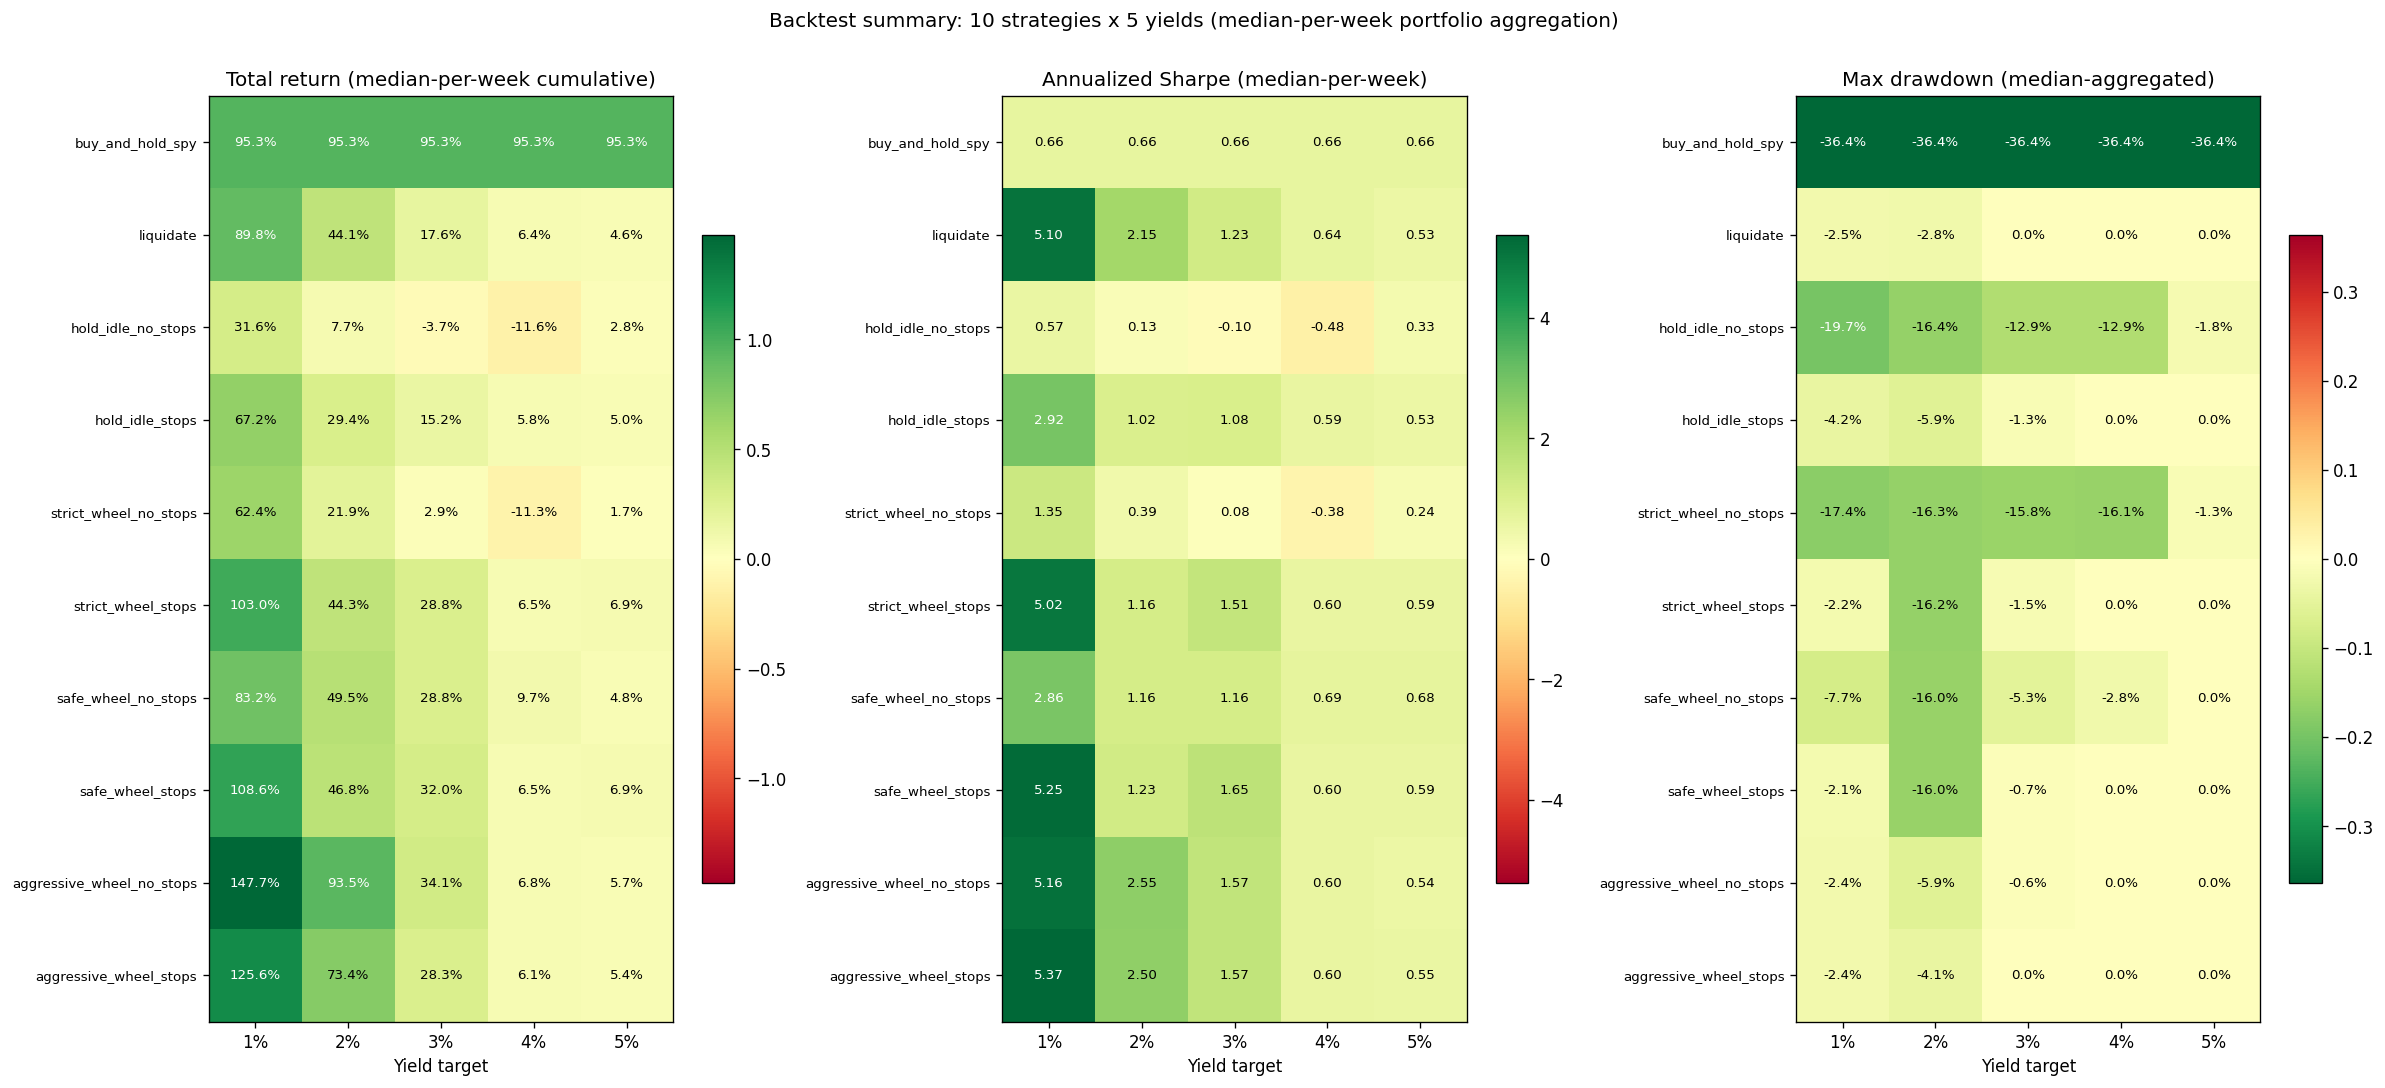

In [7]:
OUT_DIR = Path("output/06_options_income_strategies_backtesting")
OUT_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, metric, title, cmap, fmt in [
    (
        axes[0],
        "total_return",
        "Total return (arithmetic, sum of weekly)",
        "RdYlGn",
        ".1%",
    ),
    (axes[1], "sharpe", "Annualized Sharpe", "RdYlGn", ".2f"),
    (axes[2], "max_dd", "Max drawdown (in cumulative-return units)", "RdYlGn_r", ".1%"),
]:
    mat = summary.pivot(index="policy", columns="yield_target", values=metric).reindex(
        POLICIES
    )
    vmax = np.nanmax(np.abs(mat.values))
    im = ax.imshow(mat.values, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(YIELD_TARGETS)))
    ax.set_xticklabels([f"{y:.0%}" for y in YIELD_TARGETS])
    ax.set_yticks(range(len(POLICIES)))
    ax.set_yticklabels(POLICIES, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Yield target")
    for i, policy in enumerate(POLICIES):
        for j, yt in enumerate(YIELD_TARGETS):
            val = mat.values[i, j]
            txt = f"{val:{fmt}}" if pd.notna(val) else "--"
            ax.text(
                j,
                i,
                txt,
                ha="center",
                va="center",
                fontsize=8,
                color="black" if abs(val) < vmax * 0.5 else "white",
            )
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle(
    "Backtest summary: 9 policies x 5 yield targets, HQ universe 2020-2026", y=1.00
)
fig.tight_layout()
fig.savefig(OUT_DIR / "summary_heatmap.png", dpi=120)
plt.show()
plt.close(fig)

## Equity curves

5 panels, one per yield target. 9 lines per panel (log y-axis). The strict/safe/aggressive wheel variants come in matched with/without-stops pairs - compare within each pair to see how much the stops help.


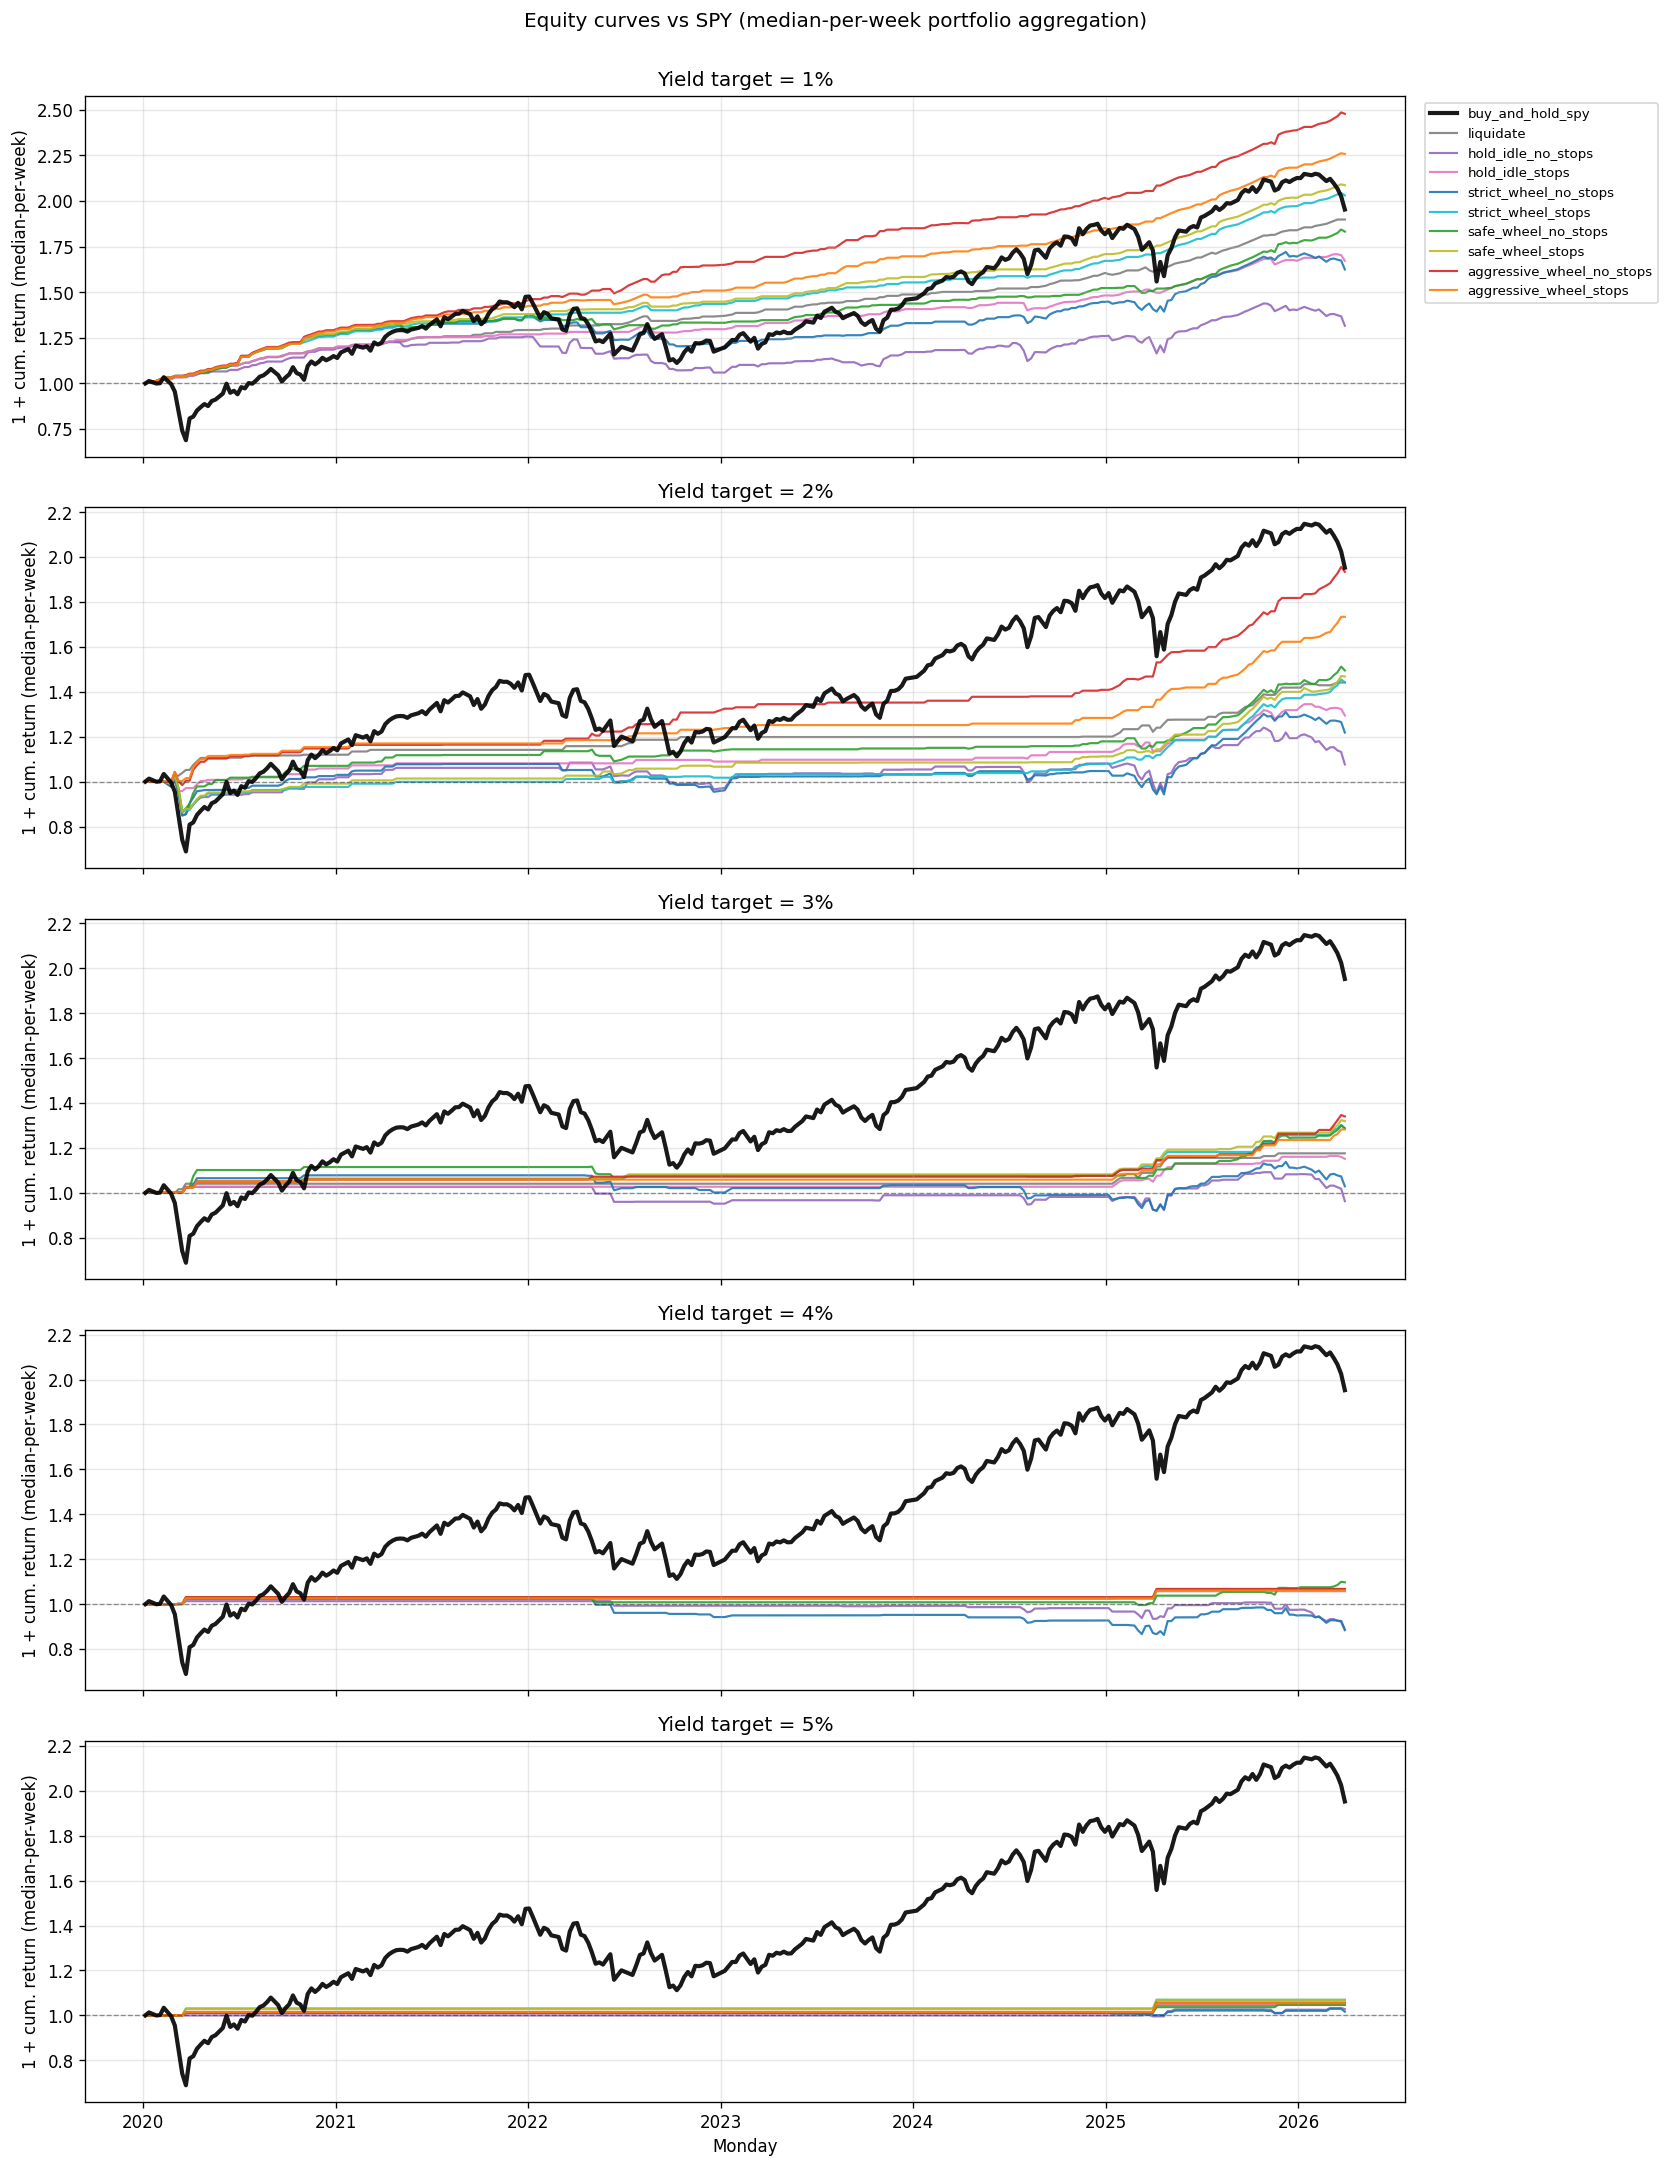

In [8]:
OUT_DIR = Path("output/06_options_income_strategies_backtesting")
OUT_DIR.mkdir(parents=True, exist_ok=True)

policy_colors = {
    "buy_and_hold": "black",
    "liquidate": "tab:gray",
    "hold_idle_no_stops": "tab:purple",
    "hold_idle_stops": "tab:pink",
    "strict_wheel_no_stops": "tab:blue",
    "strict_wheel_stops": "tab:cyan",
    "safe_wheel_no_stops": "tab:green",
    "safe_wheel_stops": "tab:olive",
    "aggressive_wheel_no_stops": "tab:red",
    "aggressive_wheel_stops": "tab:orange",
}

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
for ax, yt in zip(axes, YIELD_TARGETS):
    for policy in POLICIES:
        sub = results[(results["policy"] == policy) & (results["yield_target"] == yt)]
        weekly = portfolio_series(sub)
        if len(weekly) == 0:
            continue
        equity = 1 + weekly.cumsum()
        ax.plot(
            equity.index,
            equity.values,
            color=policy_colors[policy],
            linewidth=2.5 if policy == "buy_and_hold_spy" else 1.3,
            alpha=0.9,
            label=policy,
        )
    ax.axhline(1.0, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.set_title(f"Yield target = {yt:.0%}")
    ax.set_ylabel("1 + cum. return")
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Monday")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=True)
fig.suptitle(
    "Equity curves (arithmetic cumulative on fixed per-ticker notional)",
    fontsize=12,
    y=1.00,
)
fig.tight_layout()
fig.savefig(OUT_DIR / "equity_curves.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Drawdown curves (underwater)

Same layout as equity curves. Closer to zero = less pain. Stops should clearly reduce the depth of the worst drawdowns compared to their no-stops counterparts.


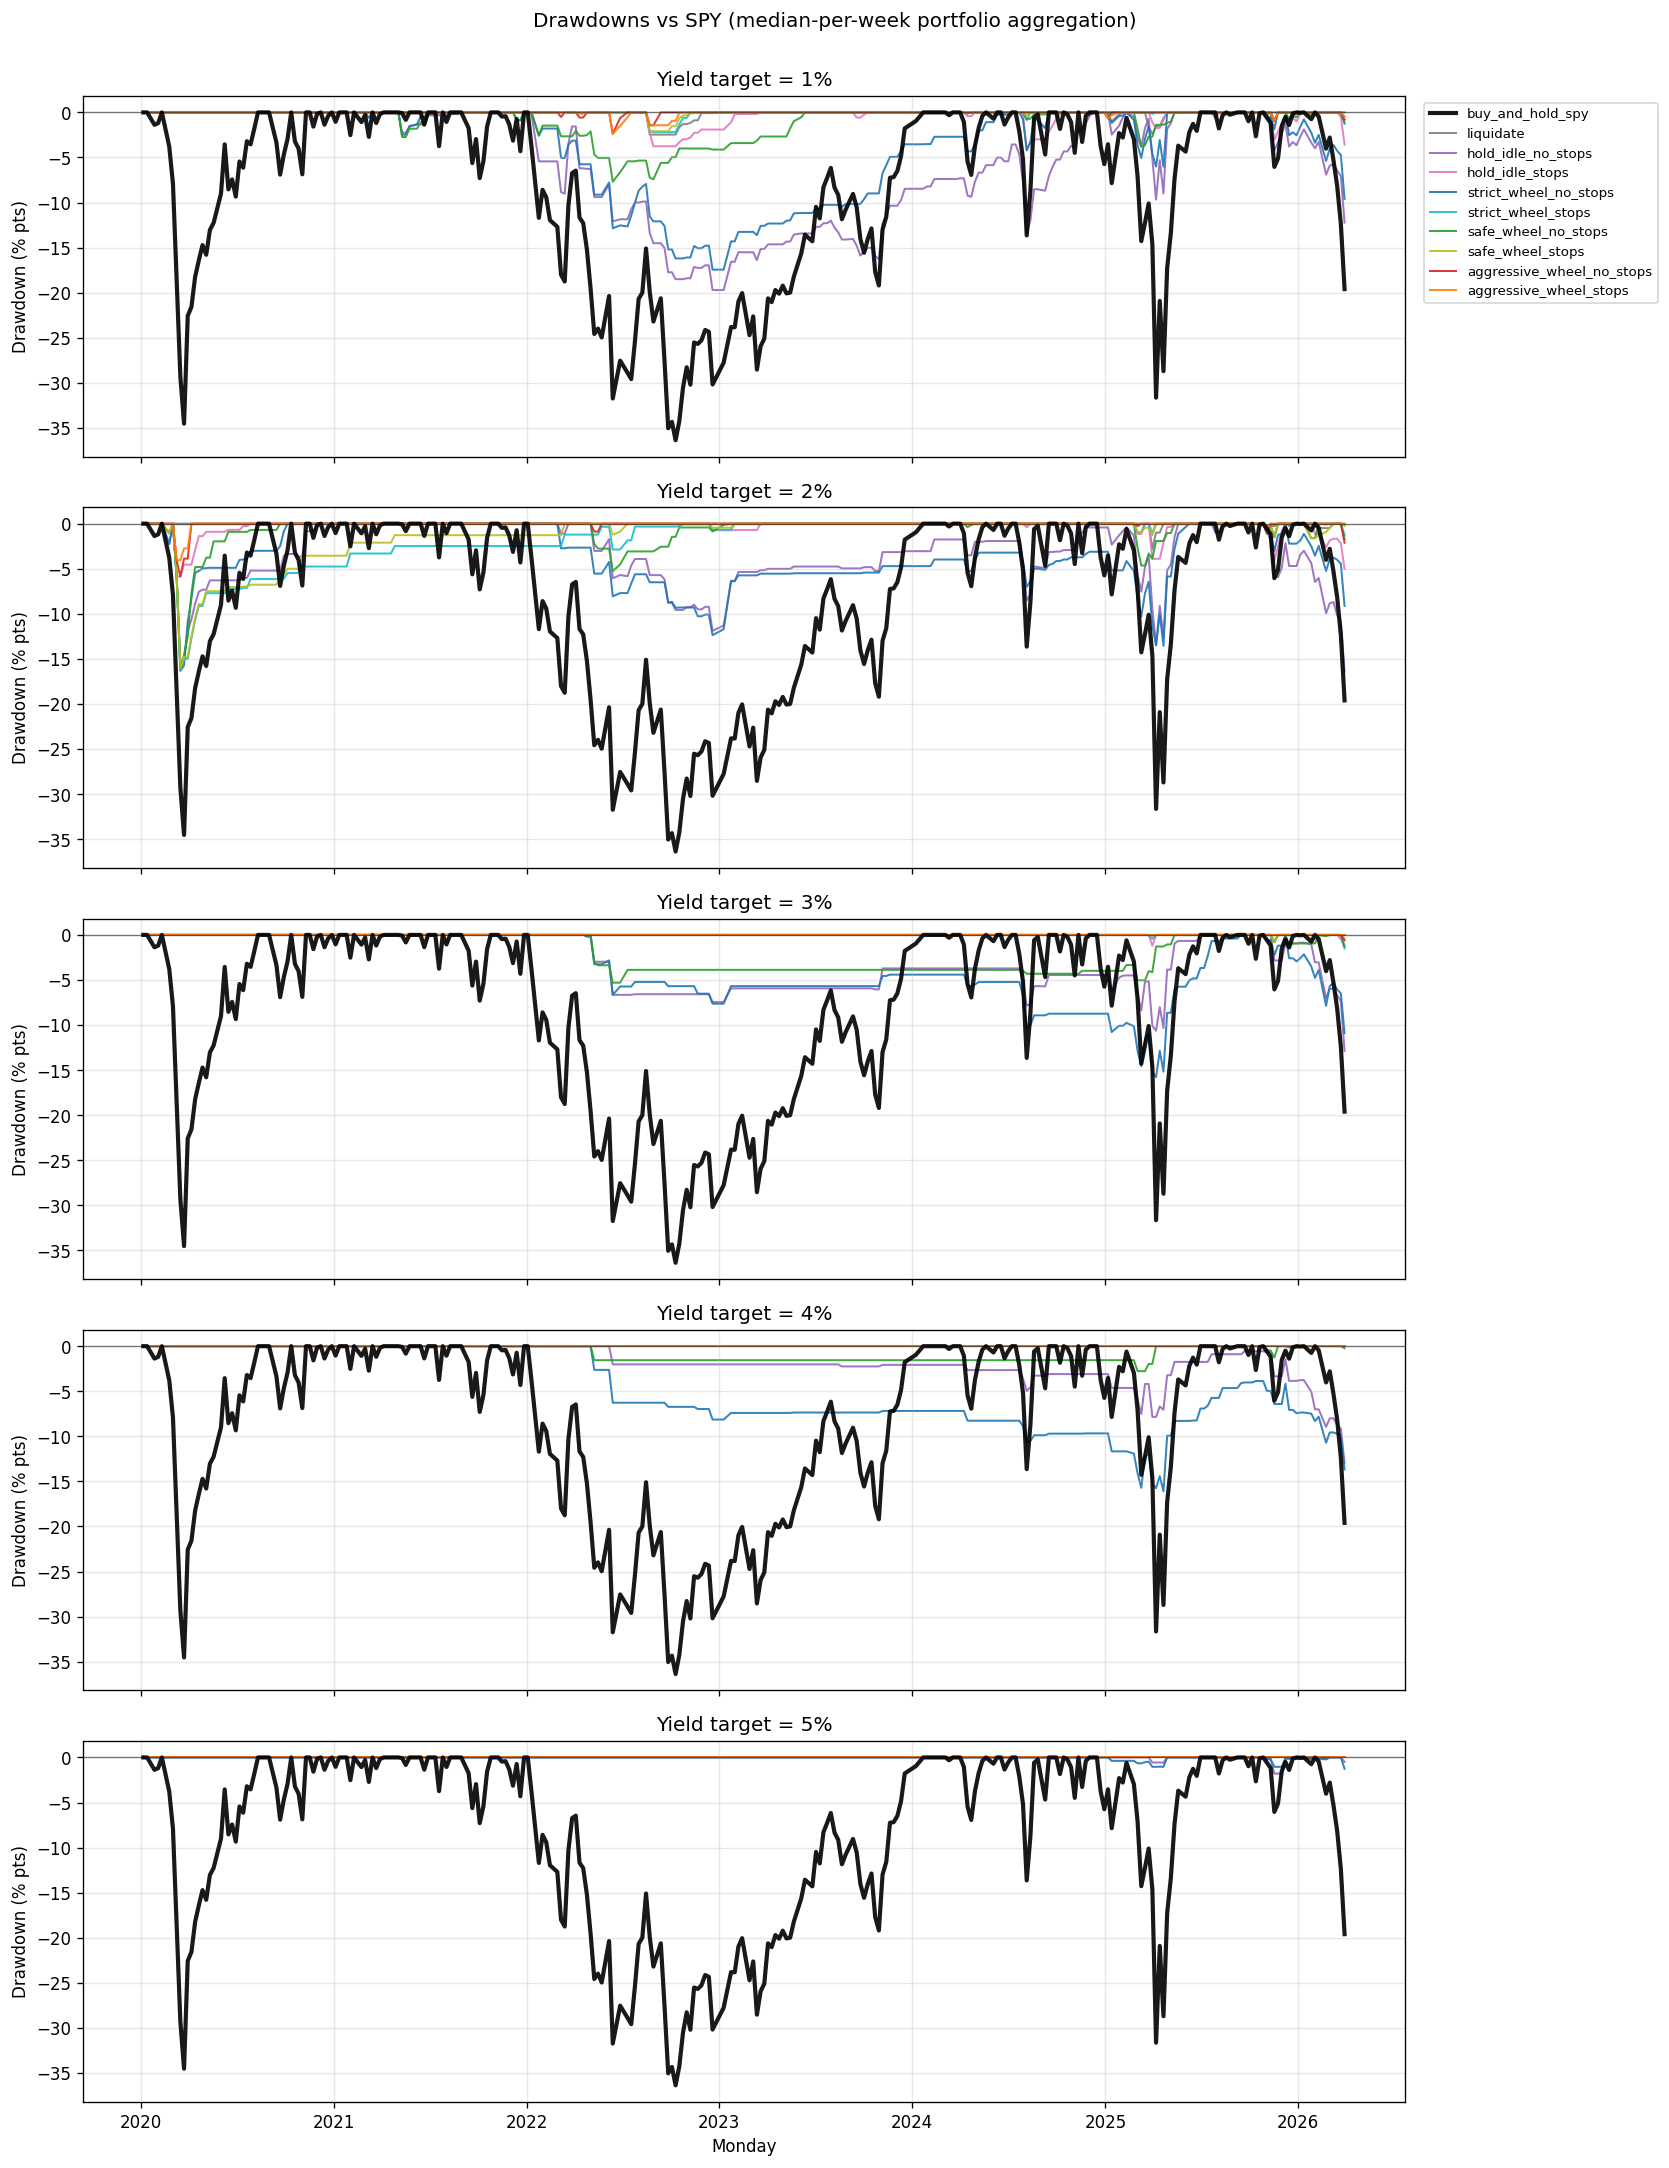

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
for ax, yt in zip(axes, YIELD_TARGETS):
    for policy in POLICIES:
        sub = results[(results["policy"] == policy) & (results["yield_target"] == yt)]
        weekly = portfolio_series(sub)
        if len(weekly) == 0:
            continue
        cum = weekly.cumsum()
        dd = cum - cum.cummax()
        ax.plot(
            dd.index,
            100 * dd.values,
            color=policy_colors[policy],
            linewidth=2.5 if policy == "buy_and_hold_spy" else 1.2,
            alpha=0.9,
            label=policy,
        )
    ax.set_title(f"Yield target = {yt:.0%}")
    ax.set_ylabel("Drawdown (% pts)")
    ax.grid(alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Monday")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=True)
fig.suptitle(
    "Drawdowns by yield target (arithmetic cumulative return minus peak)",
    fontsize=12,
    y=1.00,
)
fig.tight_layout()
fig.savefig(OUT_DIR / "drawdown_curves.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Per-ticker analysis

Since you trade one ticker at a time, the portfolio-aggregated numbers aren't the return distribution you'll experience — they're the return of a diversified book nobody would actually hold. Let's look at per-ticker results directly.

For every (ticker, policy, yield_target) combination, compute cumulative return / Sharpe / drawdown on THAT ticker's series alone. Then compare against:

- **SPY BnH** — universal "do nothing" baseline (+95% total return, 0.66 Sharpe)
- **BnH this ticker** — if you had just held the ticker itself (no options at all)

This answers: *"On my chosen ticker, does the best options strategy beat just holding that ticker, and does it beat SPY?"*


In [10]:
def metrics_series(weekly):
    import math

    if len(weekly) == 0:
        return dict(
            total_return=0.0,
            mean_weekly=0.0,
            std_weekly=0.0,
            sharpe=0.0,
            max_dd=0.0,
            n_weeks=0,
        )
    cum = weekly.cumsum()
    dd = cum - cum.cummax()
    total = float(cum.iloc[-1])
    mean_w = float(weekly.mean())
    std_w = float(weekly.std())
    sharpe = mean_w / std_w * math.sqrt(52) if std_w > 0 else 0.0
    return dict(
        total_return=total,
        mean_weekly=mean_w,
        std_weekly=std_w,
        sharpe=sharpe,
        max_dd=float(dd.min()),
        n_weeks=len(weekly),
    )


per_ticker_rows = []
for (policy, yt, ticker), sub in results.groupby(["policy", "yield_target", "ticker"]):
    weekly = sub.set_index("monday_date")["pnl_pct"].sort_index()
    per_ticker_rows.append(
        {
            "ticker": ticker,
            "policy": policy,
            "yield_target": yt,
            **metrics_series(weekly),
        }
    )
per_ticker = pd.DataFrame(per_ticker_rows)
print(
    f"per_ticker: {len(per_ticker):,} rows ({per_ticker['ticker'].nunique()} tickers x {per_ticker['policy'].nunique()} policies x {per_ticker['yield_target'].nunique()} yields)"
)

per_ticker: 1,580 rows (36 tickers x 10 policies x 5 yields)


### Heatmap: cumulative return per (ticker, policy) at 1% yield

Green = profitable, red = losing. Tickers sorted by best-strategy result (top = biggest winners).


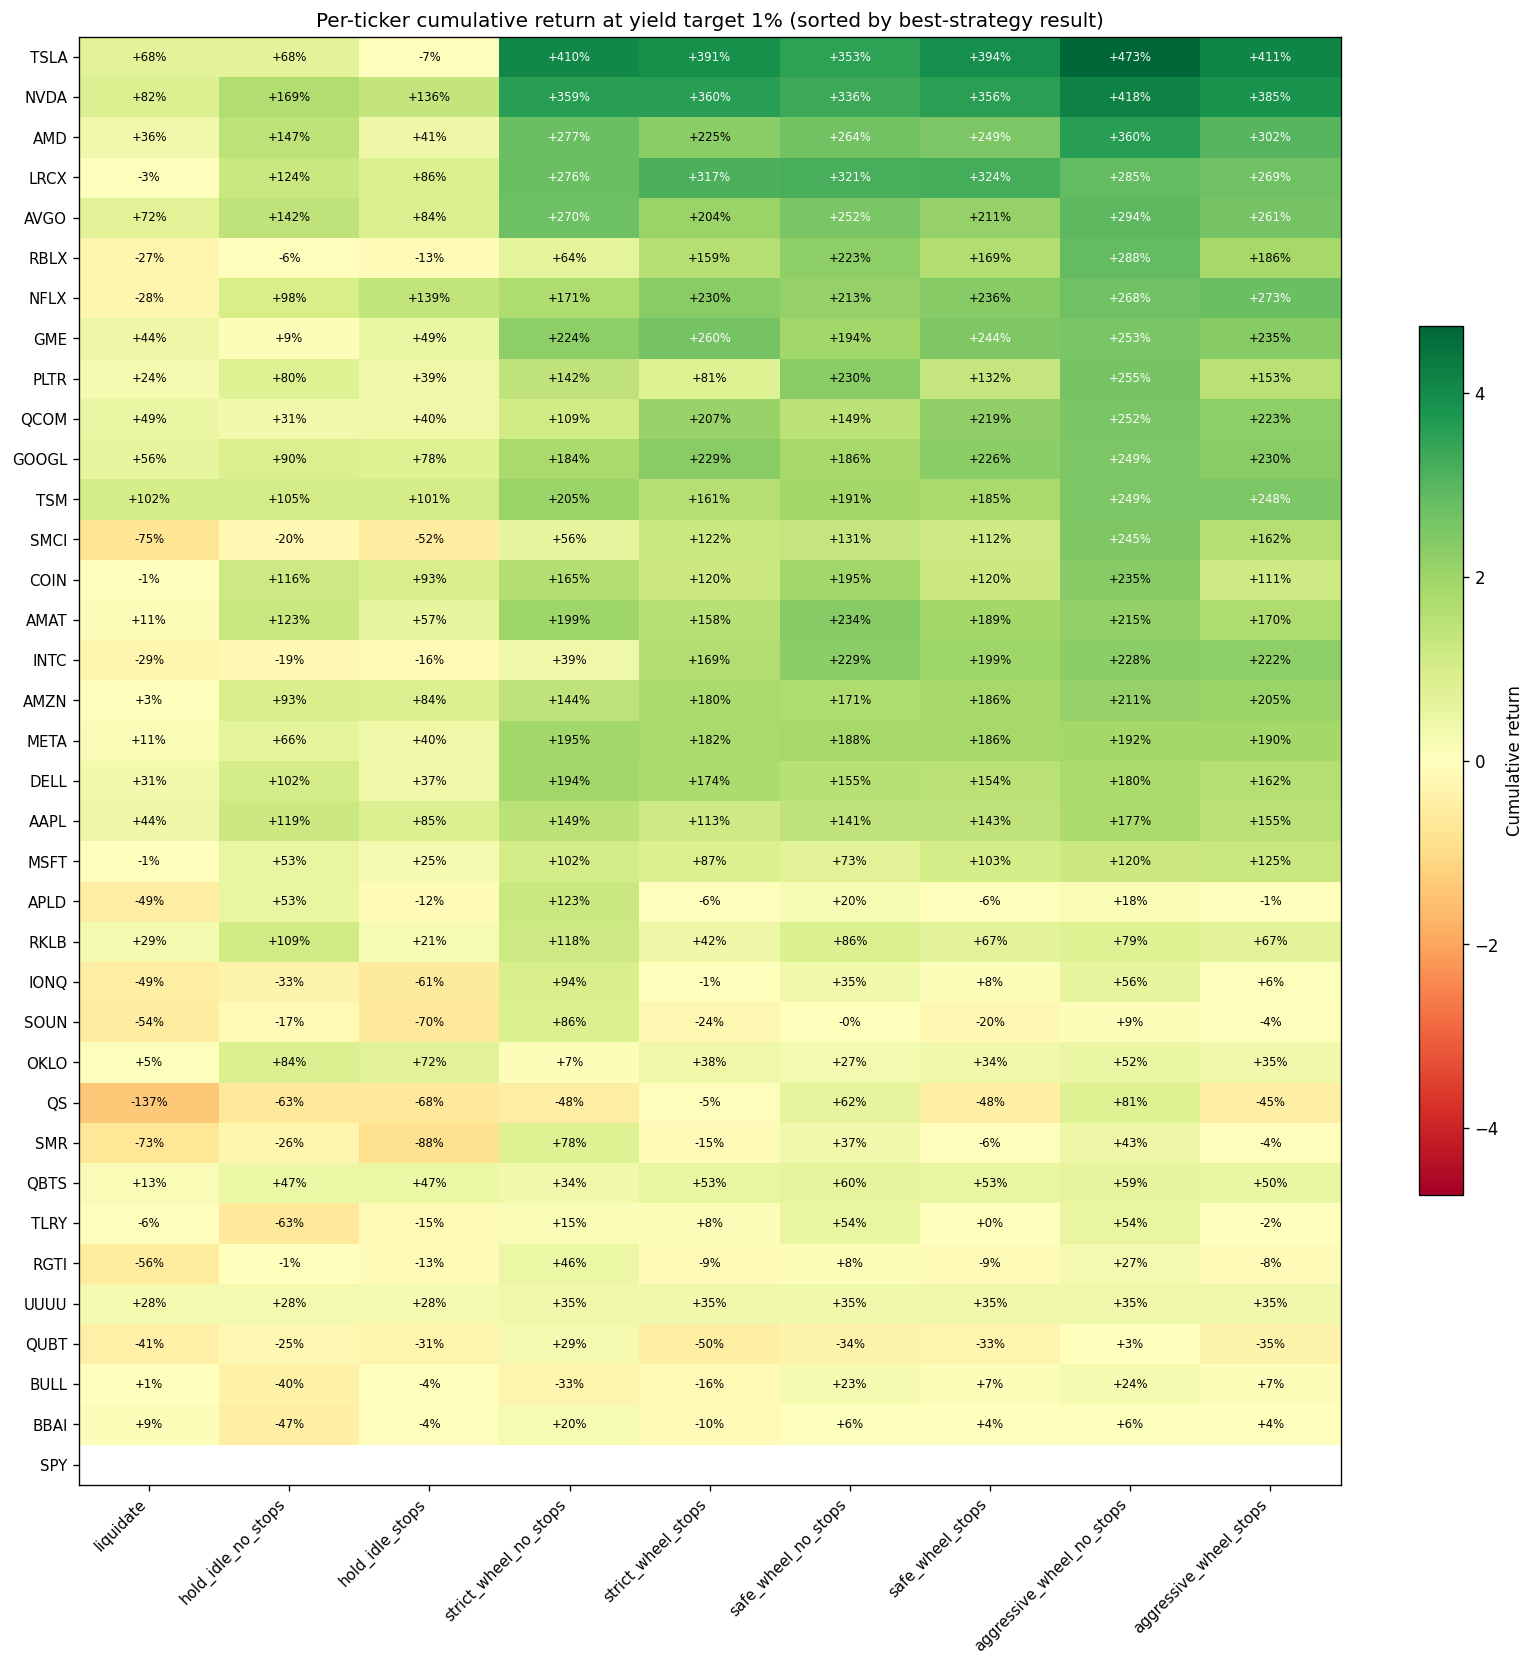

In [11]:
FOCUS_YIELD = 0.01
sub = per_ticker[per_ticker["yield_target"] == FOCUS_YIELD].copy()
pivot_return = sub.pivot(index="ticker", columns="policy", values="total_return")
pivot_return = pivot_return[[p for p in POLICIES if p in pivot_return.columns]]
pivot_return = pivot_return.loc[
    pivot_return.max(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(14, 14))
vmax = min(5.0, np.nanmax(np.abs(pivot_return.values)))
im = ax.imshow(pivot_return.values, aspect="auto", cmap="RdYlGn", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(pivot_return.columns)))
ax.set_xticklabels(pivot_return.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot_return.index)))
ax.set_yticklabels(pivot_return.index, fontsize=9)
for i in range(len(pivot_return.index)):
    for j in range(len(pivot_return.columns)):
        val = pivot_return.values[i, j]
        if pd.notna(val):
            ax.text(
                j,
                i,
                f"{100 * val:+.0f}%",
                ha="center",
                va="center",
                fontsize=7,
                color="black" if abs(val) < vmax * 0.5 else "white",
            )
fig.colorbar(im, ax=ax, shrink=0.6, label="Cumulative return")
ax.set_title(
    f"Per-ticker cumulative return at yield target {FOCUS_YIELD:.0%} (sorted by best-strategy result)"
)
fig.tight_layout()
fig.savefig(OUT_DIR / "per_ticker_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

### Best options strategy vs buy-and-hold comparison

For each ticker: green = best options strategy at 1% yield, blue = just holding that ticker, black = just holding SPY. Sorted ascending by options-strategy return. Text next to each green bar names the winning strategy for that ticker.

If green > blue, options strategy beat passive holding of that ticker.
If green > black, options strategy beat the market.


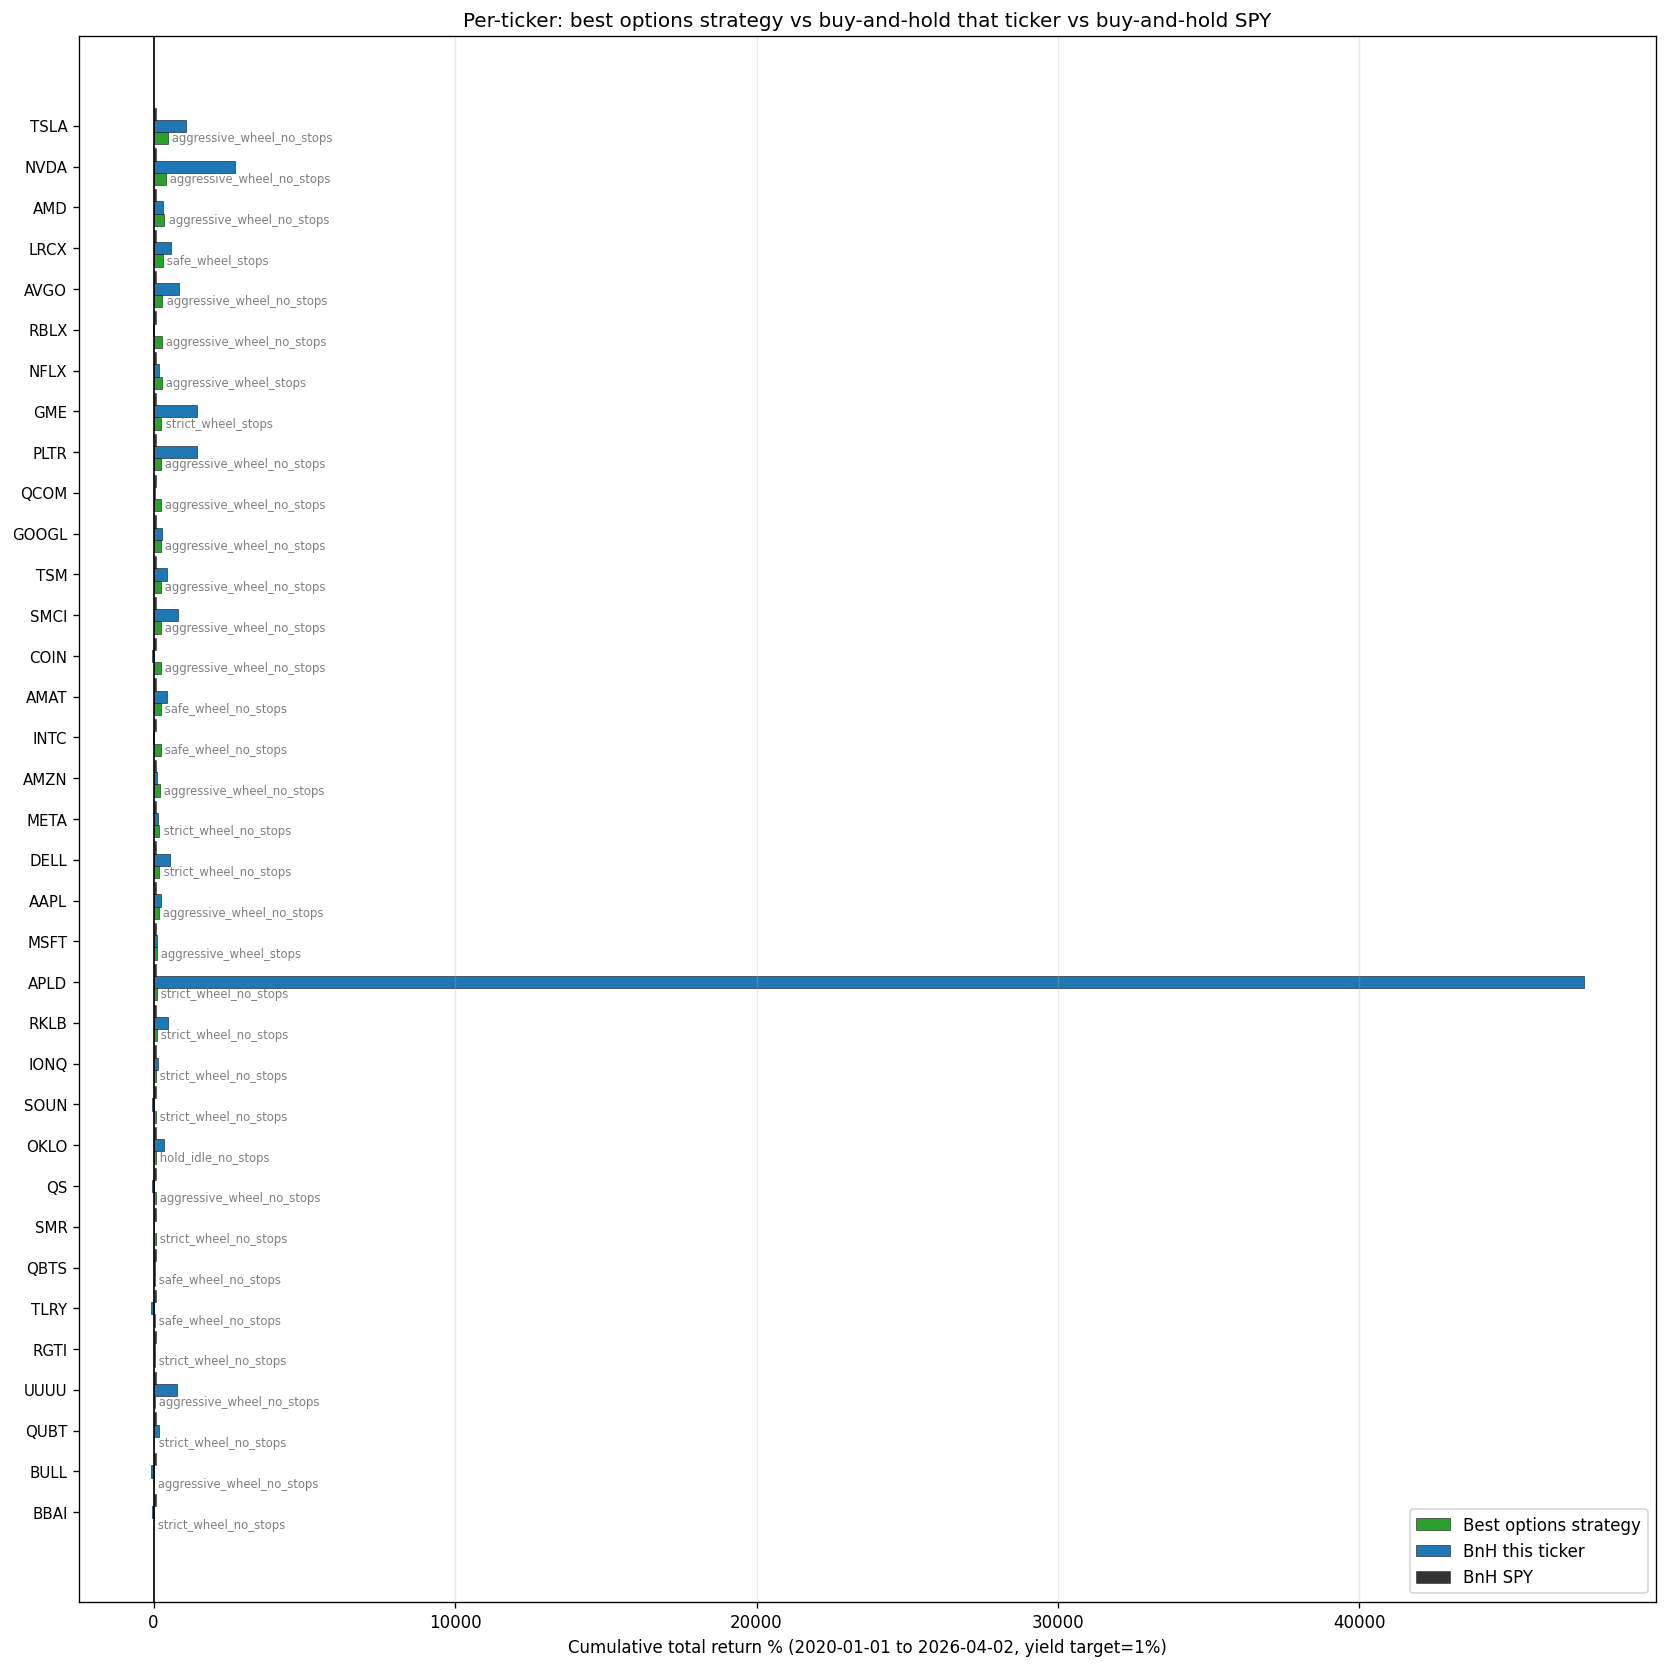

In [12]:
WINDOW_START = pd.Timestamp("2020-01-01")
WINDOW_END = pd.Timestamp("2026-04-02")
BNH_NOTIONAL = 10_000.0


def bnh_weekly_for_ticker(ticker):
    mondays = monday_list.get(ticker, [])
    if not mondays:
        return pd.Series(dtype=float)
    first_close = daily_cache[ticker].get(mondays[0])
    if first_close is None or first_close <= 0:
        return pd.Series(dtype=float)
    shares = BNH_NOTIONAL / first_close
    ref = first_close
    weekly = {mondays[0]: 0.0}
    for i in range(1, len(mondays)):
        prev_mon = mondays[i - 1]
        monday = mondays[i]
        for d, coef in split_events.get(ticker, {}).items():
            if prev_mon < d <= monday:
                shares *= coef
                ref /= coef
        cur = daily_cache[ticker].get(monday)
        if cur is None:
            weekly[monday] = 0.0
            continue
        pnl_dollars = shares * (cur - ref)
        ref = cur
        weekly[monday] = pnl_dollars / BNH_NOTIONAL
    return pd.Series(weekly).sort_index()


# Load SPY daily for reference
spy = pd.read_csv("data/daily_alpha/SPY.csv", usecols=["date", "close"])
spy["date"] = pd.to_datetime(spy["date"]).dt.date
spy = spy[
    (spy["date"] >= WINDOW_START.date()) & (spy["date"] <= WINDOW_END.date())
].sort_values("date")
daily_cache["SPY"] = dict(zip(spy["date"], spy["close"].astype(float)))
monday_list["SPY"] = sorted(d for d in daily_cache["SPY"] if d.weekday() == 0)
split_events["SPY"] = {}

spy_bnh = metrics_series(bnh_weekly_for_ticker("SPY"))
bnh_per_ticker = {
    t: metrics_series(bnh_weekly_for_ticker(t)) for t in HIGH_QUALITY_TICKERS
}

best_per_ticker = []
for t in HIGH_QUALITY_TICKERS:
    sub_t = per_ticker[
        (per_ticker["ticker"] == t) & (per_ticker["yield_target"] == FOCUS_YIELD)
    ]
    if sub_t.empty:
        continue
    best_row = sub_t.loc[sub_t["total_return"].idxmax()]
    bnh = bnh_per_ticker.get(t, {})
    best_per_ticker.append(
        {
            "ticker": t,
            "best_strategy": best_row["policy"],
            "best_strategy_return": float(best_row["total_return"]),
            "best_strategy_sharpe": float(best_row["sharpe"]),
            "bnh_ticker_return": float(bnh.get("total_return", 0)),
            "bnh_ticker_sharpe": float(bnh.get("sharpe", 0)),
            "spy_return": spy_bnh["total_return"],
        }
    )
best_df = pd.DataFrame(best_per_ticker).sort_values(
    "best_strategy_return", ascending=True
)

fig, ax = plt.subplots(figsize=(14, 14))
y = np.arange(len(best_df))
w = 0.3
ax.barh(
    y - w,
    100 * best_df["best_strategy_return"],
    w,
    color="tab:green",
    label="Best options strategy",
    edgecolor="black",
    linewidth=0.3,
)
ax.barh(
    y,
    100 * best_df["bnh_ticker_return"],
    w,
    color="tab:blue",
    label="BnH this ticker",
    edgecolor="black",
    linewidth=0.3,
)
ax.barh(
    y + w,
    100 * best_df["spy_return"],
    w,
    color="black",
    label="BnH SPY",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.8,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(best_df["ticker"], fontsize=9)
ax.set_xlabel(
    f"Cumulative total return % ({WINDOW_START.date()} to {WINDOW_END.date()}, yield target={FOCUS_YIELD:.0%})"
)
ax.set_title(
    "Per-ticker: best options strategy vs buy-and-hold that ticker vs buy-and-hold SPY"
)
ax.grid(alpha=0.3, axis="x")
ax.legend(loc="lower right")
for i, row in enumerate(best_df.itertuples()):
    ax.text(
        100 * row.best_strategy_return + (2 if row.best_strategy_return >= 0 else -2),
        i - w,
        f" {row.best_strategy}",
        va="center",
        ha="left" if row.best_strategy_return >= 0 else "right",
        fontsize=7,
        color="gray",
    )
fig.tight_layout()
fig.savefig(OUT_DIR / "per_ticker_best_vs_bnh.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

### Which strategy wins most often across tickers

For each (ticker, yield_target) combination, find the strategy with the highest cumulative return. Tally up how often each strategy wins.


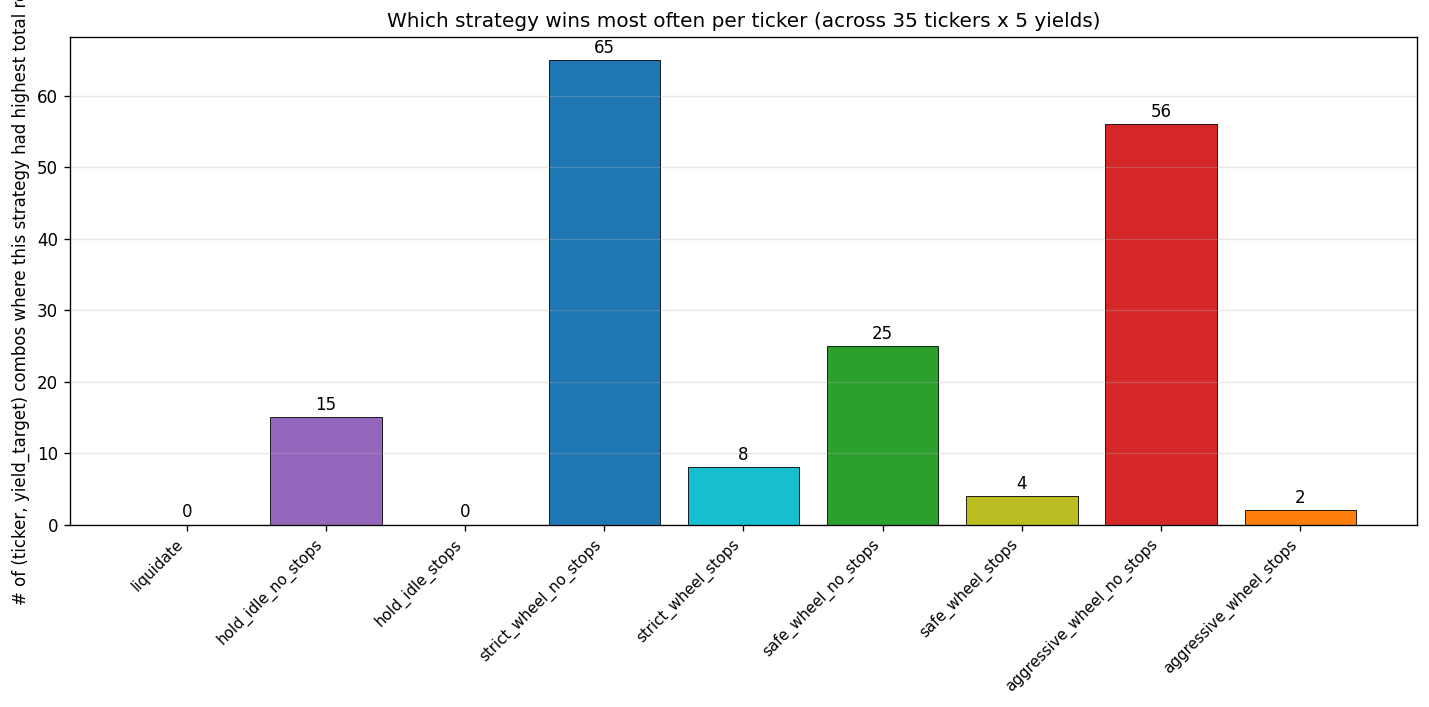

In [13]:
best_by_ticker_yield = per_ticker.loc[
    per_ticker.groupby(["ticker", "yield_target"])["total_return"].idxmax(),
    ["ticker", "yield_target", "policy", "total_return"],
].rename(columns={"policy": "best_policy"})
policy_win_counts = (
    best_by_ticker_yield["best_policy"]
    .value_counts()
    .reindex(POLICIES)
    .fillna(0)
    .astype(int)
)

colors = {
    "liquidate": "tab:gray",
    "hold_idle_no_stops": "tab:purple",
    "hold_idle_stops": "tab:pink",
    "strict_wheel_no_stops": "tab:blue",
    "strict_wheel_stops": "tab:cyan",
    "safe_wheel_no_stops": "tab:green",
    "safe_wheel_stops": "tab:olive",
    "aggressive_wheel_no_stops": "tab:red",
    "aggressive_wheel_stops": "tab:orange",
}

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    policy_win_counts.index,
    policy_win_counts.values,
    color=[colors[p] for p in policy_win_counts.index],
    edgecolor="black",
    linewidth=0.5,
)
for bar, count in zip(bars, policy_win_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{count}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_xticklabels(policy_win_counts.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel(
    "# of (ticker, yield_target) combos where this strategy had highest total return"
)
ax.set_title(
    f"Which strategy wins most often per ticker (across {len(HIGH_QUALITY_TICKERS)} tickers x {len(YIELD_TARGETS)} yields)"
)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(OUT_DIR / "per_ticker_strategy_winners.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

### Per-ticker detail table (best strategy at 1% yield)

Columns:
- `best_policy` - strategy with highest total return on this ticker
- `best_total_ret` / `best_sharpe` / `best_max_dd` - stats under that strategy
- `bnh_ticker_ret` / `bnh_ticker_sharpe` / `bnh_ticker_max_dd` - what you'd have earned just holding the ticker
- `options_beats_bnh` - did best options strategy beat passive holding on this ticker?
- `options_beats_spy` - did it beat SPY (+95% BnH)?


In [14]:
detail_rows = []
for t in HIGH_QUALITY_TICKERS:
    sub_t = per_ticker[
        (per_ticker["ticker"] == t) & (per_ticker["yield_target"] == FOCUS_YIELD)
    ]
    if sub_t.empty:
        continue
    best = sub_t.loc[sub_t["total_return"].idxmax()]
    bnh = bnh_per_ticker.get(t, {})
    detail_rows.append(
        {
            "ticker": t,
            "best_policy": best["policy"],
            "best_total_ret": round(100 * float(best["total_return"]), 1),
            "best_sharpe": round(float(best["sharpe"]), 2),
            "best_max_dd": round(100 * float(best["max_dd"]), 1),
            "bnh_ticker_ret": round(100 * bnh.get("total_return", 0), 1),
            "bnh_ticker_sharpe": round(bnh.get("sharpe", 0), 2),
            "bnh_ticker_max_dd": round(100 * bnh.get("max_dd", 0), 1),
            "options_beats_bnh": "Y"
            if float(best["total_return"]) > bnh.get("total_return", 0)
            else "N",
            "options_beats_spy": "Y"
            if float(best["total_return"]) > spy_bnh["total_return"]
            else "N",
        }
    )
detail_df = pd.DataFrame(detail_rows).sort_values("best_total_ret", ascending=False)
detail_df

,ticker,best_policy,best_total_ret,best_sharpe,best_max_dd,bnh_ticker_ret,bnh_ticker_sharpe,bnh_ticker_max_dd,options_beats_bnh,options_beats_spy
32,TSLA,aggressive_wheel_no_stops,472.8,1.93,-28.8,1080.2,0.35,-940.4,N,Y
18,NVDA,aggressive_wheel_no_stops,418.0,2.02,-10.7,2687.0,0.77,-886.2,N,Y
2,AMD,aggressive_wheel_no_stops,360.4,2.45,-21.6,305.1,0.39,-251.5,Y,Y
14,LRCX,safe_wheel_stops,324.3,1.37,-18.6,591.3,0.78,-165.8,N,Y
5,AVGO,aggressive_wheel_no_stops,293.7,2.31,-23.5,835.3,0.61,-343.3,N,Y
25,RBLX,aggressive_wheel_no_stops,287.8,2.11,-17.5,-28.1,-0.11,-145.2,Y,Y
17,NFLX,aggressive_wheel_stops,273.5,2.68,-16.7,176.8,0.41,-172.4,Y,Y
10,GME,strict_wheel_stops,260.0,0.85,-69.8,1422.7,0.10,-4102.1,N,Y
20,PLTR,aggressive_wheel_no_stops,255.3,1.79,-27.2,1423.3,0.59,-848.1,N,Y
22,QCOM,aggressive_wheel_no_stops,252.1,2.24,-21.6,46.9,0.14,-110.0,Y,Y
